## Objective
Analyze housing data using statistical methods and improve ML performance through preprocessing.

## Steps:
1. Data exploration
2. Distribution analysis
3. Outlier detection
4. Transformation
5. Model comparison

In [66]:
%pip install numpy pandas scipy matplotlib seaborn scikit-learn

In [67]:
# load datasets

from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [68]:
# Basic Stats
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Mean vs Median Analysis

**Features with significant mean-median differences (indicating skewness):**

- **Population**: Mean (1,425) > Median (1,166) - Right-skewed
- **AveOccup**: Mean (3.07) > Median (2.82) - Right-skewed  
- **AveRooms**: Mean (5.43) > Median (5.23) - Slightly right-skewed
- **AveBedrms**: Mean (1.10) > Median (1.05) - Slightly right-skewed
- **target**: Mean (2.07) > Median (1.80) - Right-skewed

**Features with relatively symmetric distributions:**
- **MedInc**: Mean (3.87) ≈ Median (3.53) - Minor right skew
- **HouseAge**: Mean (28.64) ≈ Median (29.00) - Nearly symmetric
- **Latitude/Longitude**: Geographic coordinates, mean≈median as expected

## Most Skewed Features

1. **Population** (most skewed): Max value 35,682 vs 75th percentile 1,725
2. **AveOccup**: Max value 1,243 vs 75th percentile 3.28
3. **target**: Max value 5.00 vs 75th percentile 2.65

The right-skewed features have outliers with extremely high values pulling the mean above the median, suggesting potential data quality issues or the need for log transformation.

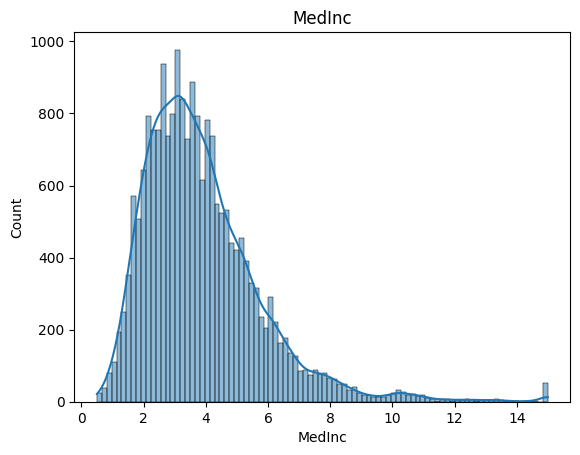

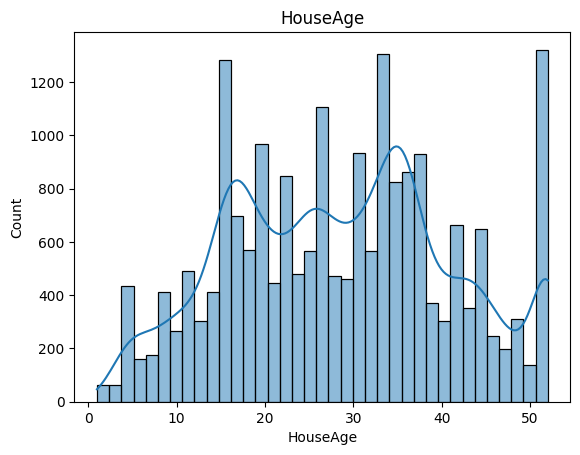

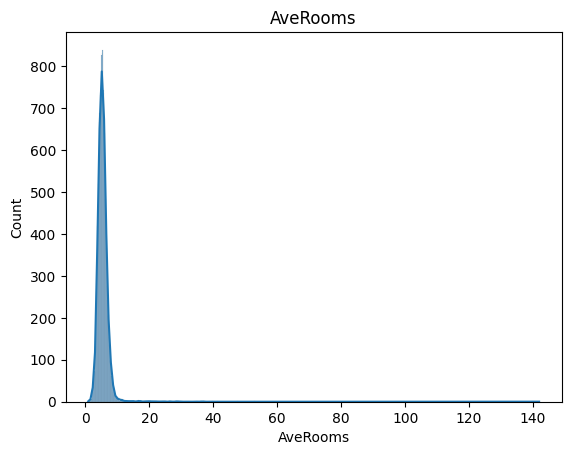

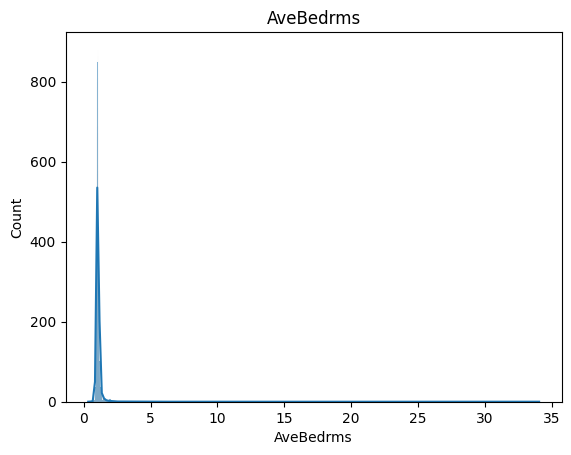

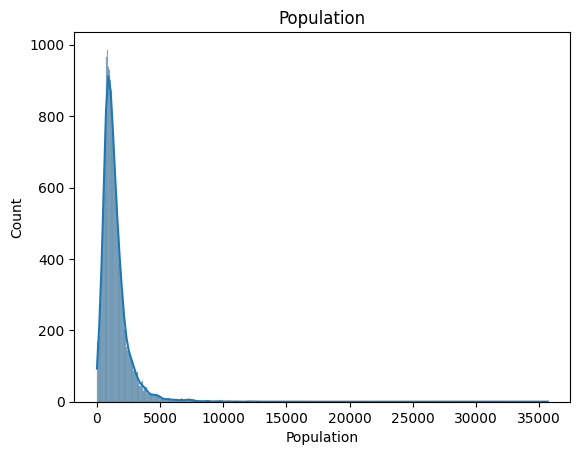

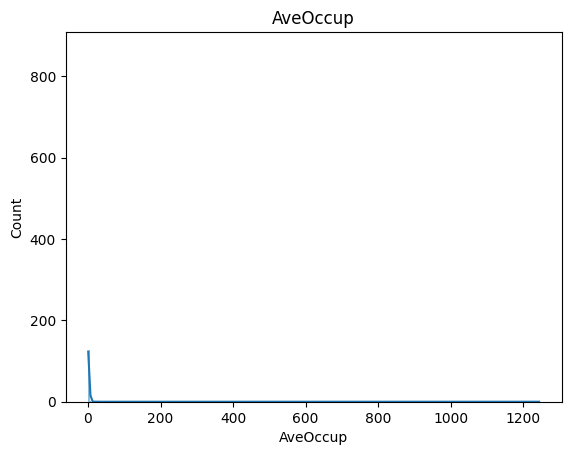

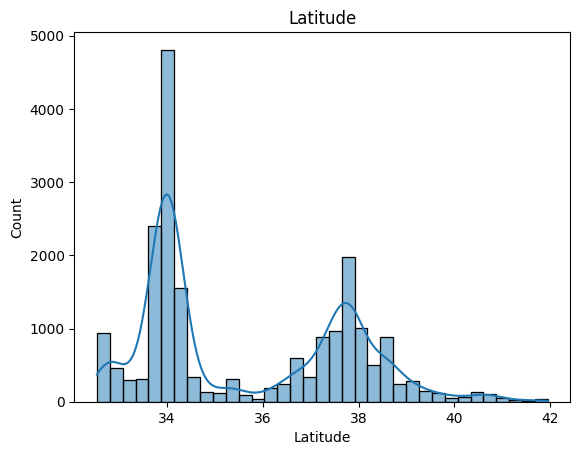

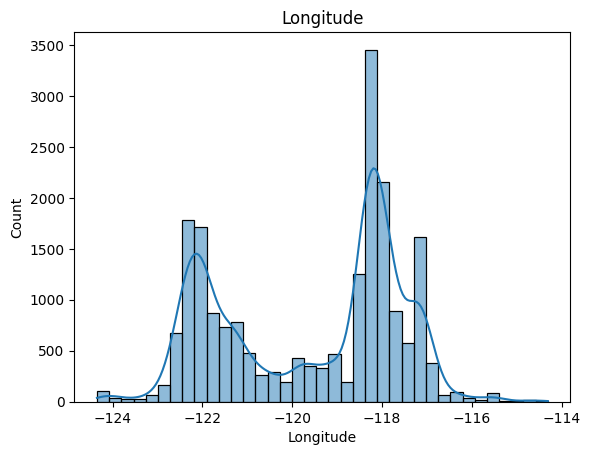

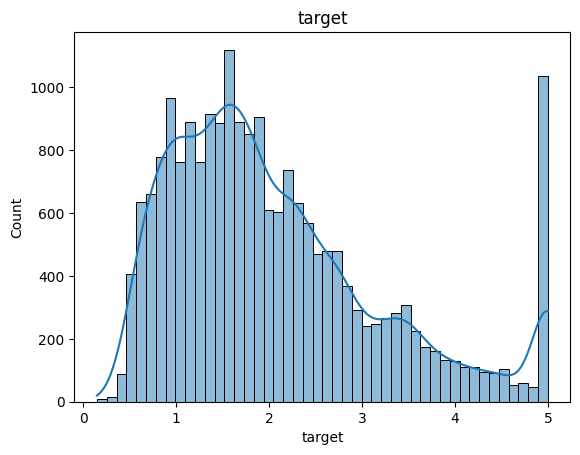

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.columns:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

👉 Write:

Which look normal?
Which are skewed?

In [72]:
# Skewness & Kurtosis
from scipy.stats import skew, kurtosis

import pandas as pd

# Create a DataFrame with the results
results = pd.DataFrame({'column': df.columns,'skew': df.apply(skew),'kurtosis': df.apply(kurtosis)})

# Print the results in a nice format
# print(results.to_string(index=False))
results

,column,skew,kurtosis
MedInc,MedInc,1.646537,4.951034
HouseAge,HouseAge,0.060326,-0.800726
AveRooms,AveRooms,20.696365,879.139966
AveBedrms,AveBedrms,31.314680,1636.315218
Population,Population,4.935500,73.535009
AveOccup,AveOccup,97.632465,10648.430334
Latitude,Latitude,0.465919,-1.117780
Longitude,Longitude,-0.297780,-1.330121
target,target,0.977692,0.327500


👉 Explain:

Which features are highly skewed (>1)?
Which have heavy tails?

In [73]:
# Outlier Detection
from scipy.stats import zscore
import numpy as np

z = np.abs(zscore(df))
df_z = df[(z < 3).all(axis=1)]

In [74]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_iqr = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [75]:
df_iqr

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
...,...,...,...,...,...,...,...,...,...
20634,3.7125,28.0,6.779070,1.148256,1041.0,3.026163,39.27,-121.56,1.168
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


👉 Write comparison:

Which removed more rows?
Which seems safer?

In [76]:
# Fix Skewness
import numpy as np

df_log = df.copy()

for col in df.columns:
    if abs(skew(df[col])) > 1:
        df_log[col] = np.log1p(df_log[col])

Text(0.5, 1.0, 'Before')

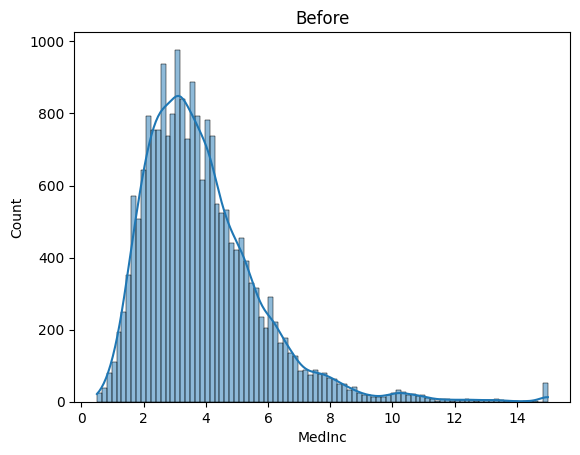

In [78]:
sns.histplot(df['MedInc'], kde=True)
plt.title("Before")



Text(0.5, 1.0, 'After')

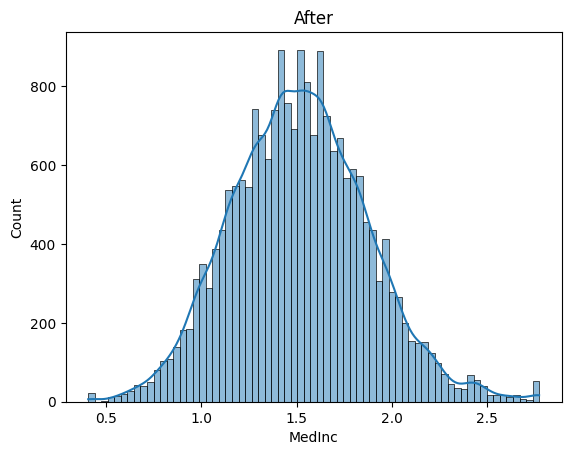

In [79]:
sns.histplot(df_log['MedInc'], kde=True)
plt.title("After")

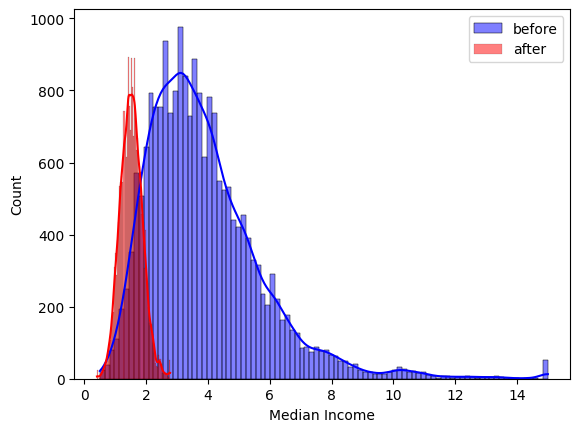

In [80]:
fig, ax = plt.subplots()
sns.histplot(data=df, x='MedInc', ax=ax, label='before', kde=True, color='blue')
sns.histplot(data=df_log, x='MedInc', ax=ax, label='after', kde=True, color='red')

# Add labels and legend
ax.set_xlabel('Median Income')
ax.set_ylabel('Count')
ax.legend()

# Show the plot
plt.show()


In [81]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_log)

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [83]:
def train(df):
    X = df.drop('target', axis=1)
    y = df['target']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    return model.score(X_test, y_test)

In [84]:
print("Raw:", train(df))
print("Z-score:", train(df_z))
print("IQR:", train(df_iqr))
print("Transformed:", train(pd.DataFrame(df_scaled, columns=df.columns)))

Raw: 0.6121762521552647
Z-score: 0.6222691057938032
IQR: 0.6333296910591139
Transformed: 0.636494485548319
